## Intro

In [1]:
# to read and wrangle data
import pandas as pd

# to import data from LA Data portal
from sodapy import Socrata

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# For spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# to illustrate, bring in tracts
gdf_tracts = gpd.read_file('Group Data/2020_Census_Tracts.geojson')

In [3]:
# population block group data from census reporter
# gdf_bg = gpd.read_file('data/acs2019_5yr_B01003_15000US060372672002.geojson')
gdf_mhhi = gpd.read_file('Group Data/tracts_mhhi_geojson_output.geojson')

<Axes: >

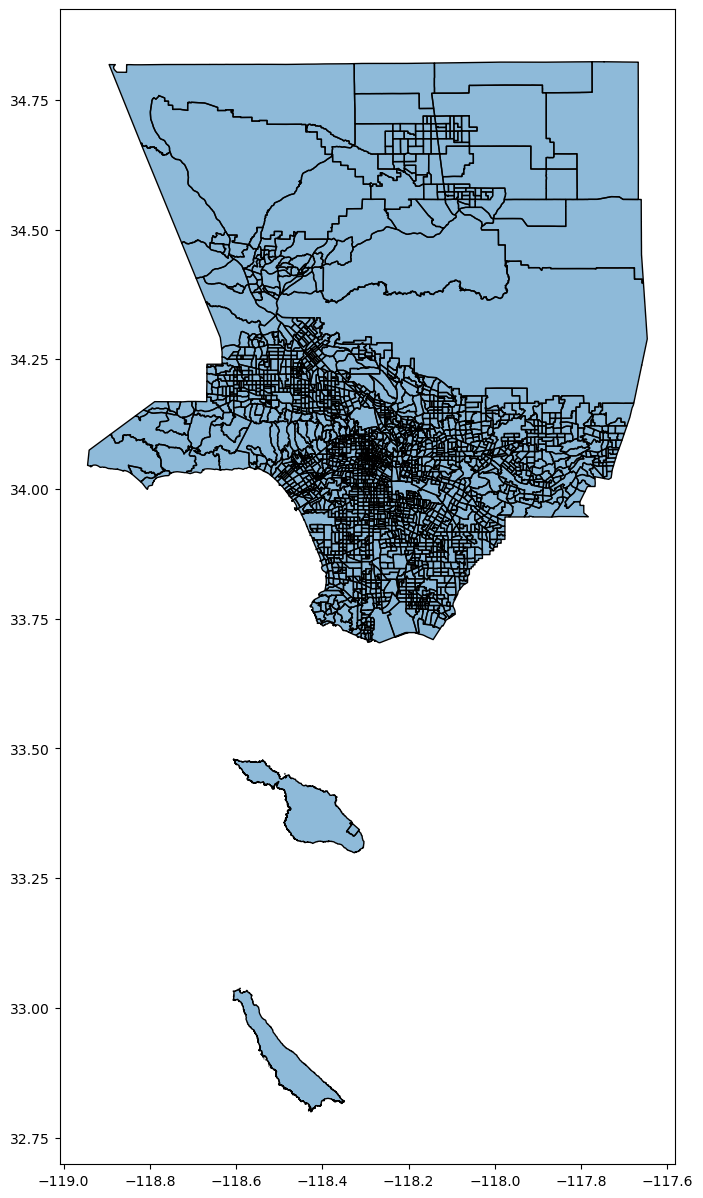

In [29]:
# compare
fig,ax = plt.subplots(figsize=(15,15))

# blue background of census tracts
gdf_tracts.plot(ax=ax,zorder=10,alpha=0.5)

# while lines to show block groups (sandwiched between the two layers above for visual clarity)
gdf_mhhi.boundary.plot(ax=ax,color='white',zorder=15,lw=0.5)

# black boundary lines of census tracts on top of everything
gdf_tracts.boundary.plot(ax=ax,color='black',zorder=20,lw=1)

(33.09959502307935, 34.52330696822776)

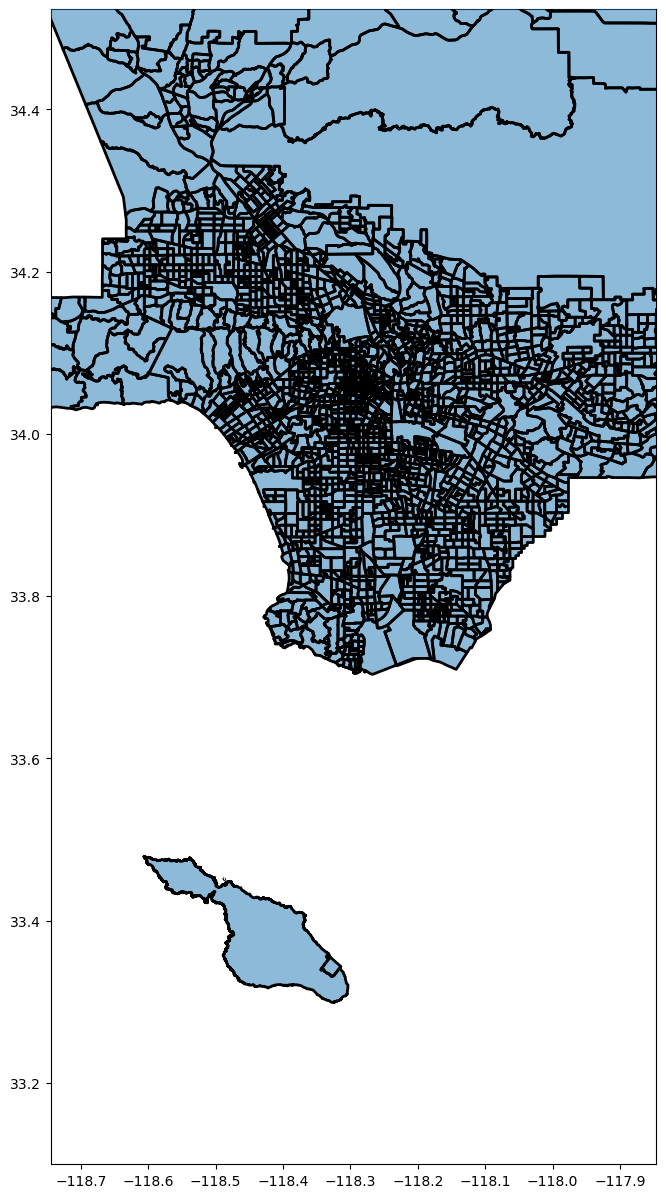

In [30]:
# compare
fig,ax = plt.subplots(figsize=(20,15))

# blue background of census tracts
gdf_tracts.plot(ax=ax,zorder=10,alpha=0.5)

# black boundary of census tracts
gdf_tracts.boundary.plot(ax=ax,color='black',zorder=20,lw=2)

# while lines to show block groups (sandwiched between the two layers above for visual clarity)
gdf_mhhi.boundary.plot(ax=ax,color='white',zorder=15,lw=0.8,linestyle='--')

# zoom in

# get the total bounds
minx,miny,maxx,maxy = gdf_mhhi.total_bounds

# set the x and y limits manually
ax.set_xlim(minx+0.2,maxx-0.2) # zooming in just a bit
ax.set_ylim(miny+0.3,maxy-0.3)

In [11]:
# what does our data look like?
gdf_mhhi.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   CT20                    2495 non-null   object  
 1   FIPS                    2495 non-null   object  
 2   tract                   2495 non-null   object  
 3   med_hh_income           2458 non-null   float64 
 4   med_hh_income_universe  2495 non-null   int32   
 5   ami_category            2458 non-null   object  
 6   below_med_income        2458 non-null   object  
 7   below_60pct_med_income  2458 non-null   object  
 8   below_moderate_income   2458 non-null   object  
 9   sup_dist                2495 non-null   object  
 10  csa                     2495 non-null   object  
 11  spa                     2495 non-null   object  
 12  ESRI_OID                2495 non-null   int32   
 13  Shape__Area             2495 non-null   float64 
 14  Shape__Length   

In [12]:
gdf_mhhi.tail()

,CT20,FIPS,tract,med_hh_income,med_hh_income_universe,ami_category,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area,Shape__Length,geometry
2490,577200,6037577200,6037577200,88520.0,3178,Low Income,No,No,Yes,District 4,City of Long Beach,SPA 8 - South Bay,2730,9.192743e+06,13068.708351,"POLYGON ((-118.15164 33.76626, -118.15242 33.7..."
2491,577300,6037577300,6037577300,90202.0,3641,Low Income,No,No,Yes,District 4,City of Long Beach,SPA 8 - South Bay,2731,8.753222e+06,12674.194794,"POLYGON ((-118.13269 33.75305, -118.13235 33.7..."
2492,577504,6037577504,6037577504,96411.0,763,Above Moderate Income,No,No,No,District 4,City of Long Beach,SPA 8 - South Bay,2734,6.017113e+06,16934.855734,"POLYGON ((-118.13009 33.75447, -118.13067 33.7..."
2493,599100,6037599100,6037599100,NaN,79,None,None,None,None,District 4,Unincorporated - Santa Catalina Island,SPA 8 - South Bay,2851,3.698756e+09,554591.259931,"MULTIPOLYGON (((-118.60595 33.47899, -118.6059..."
2494,599000,6037599000,6037599000,78254.0,1637,Low Income,Yes,No,Yes,District 4,City of Avalon,SPA 8 - South Bay,2850,3.566450e+07,28399.116302,"POLYGON ((-118.33163 33.35634, -118.33173 33.3..."


Map

In [4]:
gdf_mhhi = gdf_mhhi.to_crs(epsg=3857)

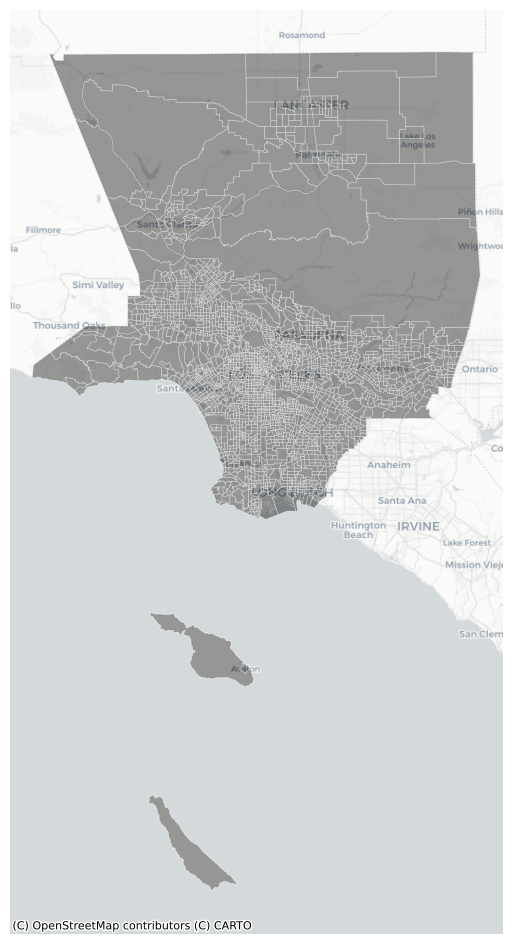

In [14]:
# plot it!
fig, ax = plt.subplots(figsize=(12,12))

gdf_mhhi.plot(ax=ax,
         color='black', 
         edgecolor='white',
         lw=0.5,
         alpha=0.4)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# Load dataset
df = pd.read_csv("Group Data/coastliveoaksobservations.csv") 


# Convert DataFrame to GeoDataFrame
trees= gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

In [34]:
trees.head()

,observed_on,updated_at,num_identification_agreements,place_guess,latitude,longitude,positional_accuracy,public_positional_accuracy,scientific_name,common_name,geometry
0,1/29/2012,2021-01-20 01:40:48 UTC,1,"34.03779220581055, -118.750244140625",34.037792,-118.750244,5.0,5.0,Quercus agrifolia,coast live oak,POINT (-13219216.705 4033877.726)
1,3/6/2012,2015-07-01 01:06:17 UTC,3,Central Hahamongna Park,34.193470,-118.175340,NaN,NaN,Quercus agrifolia,coast live oak,POINT (-13155218.64 4054809.979)
2,3/22/2012,2015-07-01 01:16:52 UTC,3,Eaton Canyon,34.193066,-118.104315,NaN,NaN,Quercus agrifolia,coast live oak,POINT (-13147312.184 4054755.637)
3,6/15/2012,2021-01-20 01:40:40 UTC,1,Santa Monica Mountains,34.060028,-118.932694,55.0,55.0,Quercus agrifolia,coast live oak,POINT (-13239526.89 4036865.192)
4,7/4/2012,2016-05-17 20:01:59 UTC,2,Eaton Canyon park,34.184842,-118.095442,811.0,811.0,Quercus agrifolia,coast live oak,POINT (-13146324.491 4053648.918)


In [7]:
trees = trees.to_crs(epsg=3857)

In [8]:
trees.lon = trees.longitude.astype('float')
trees.lat = trees.latitude.astype('float')

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  super().__setattr__(attr, val)
/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  super().__setattr__(attr, val)


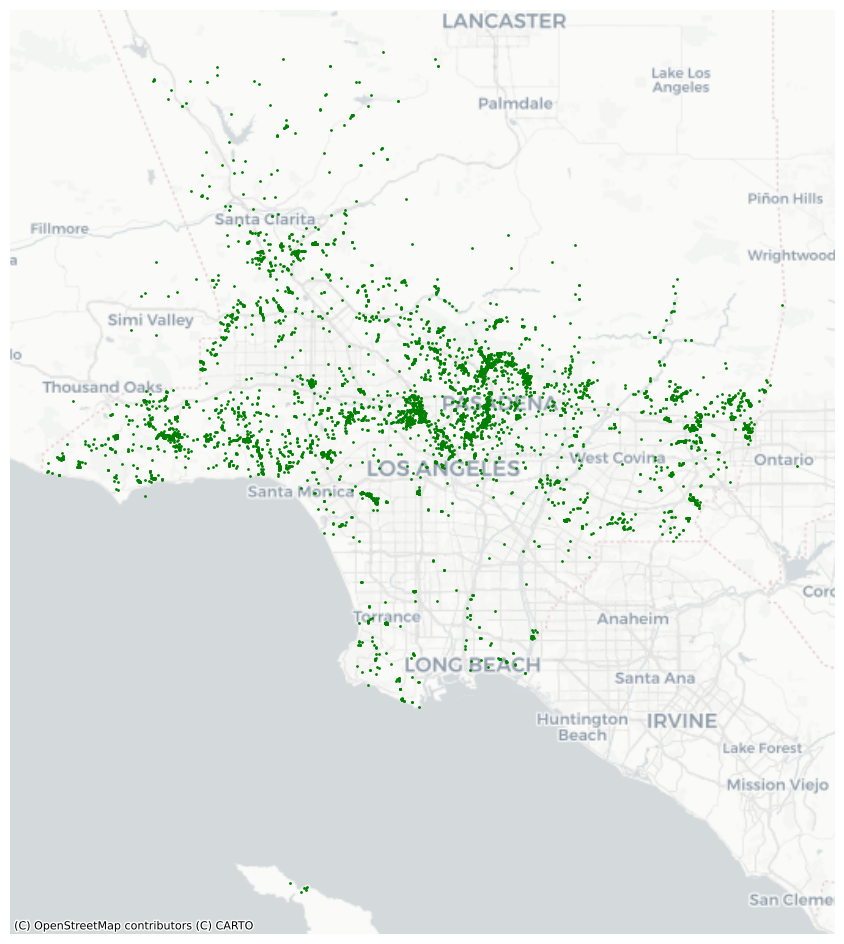

In [9]:
fig,ax = plt.subplots(figsize=(12,12))

trees.plot(ax=ax,
             color='green',
             markersize=1)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

In [10]:
minx, miny, maxx, maxy = trees.geometry.total_bounds
print(minx)
print(maxx)
print(miny)
print(maxy)

-13239652.525401736
-13093930.402763797
3953517.0160878
4116759.9180934634


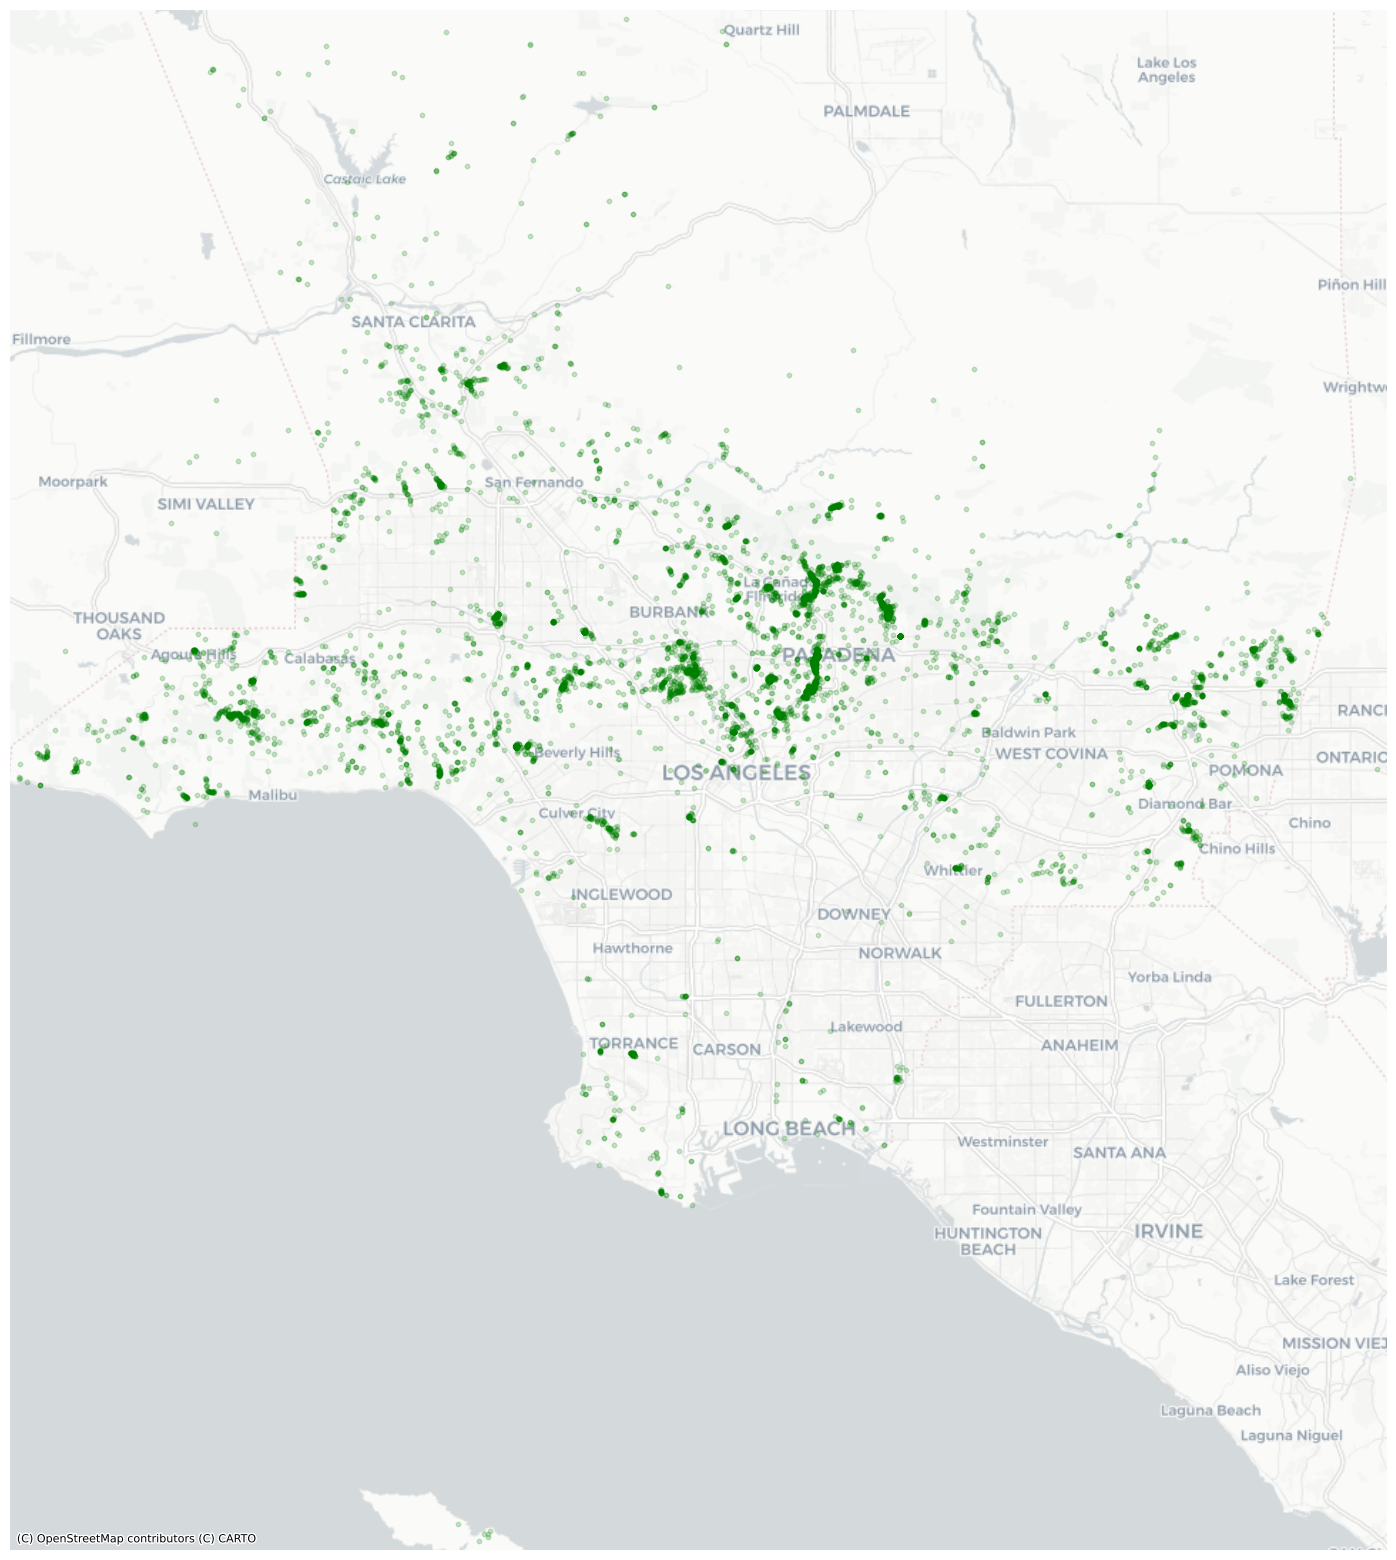

In [59]:
# set up the plot canvas with plt.subplots
fig, ax = plt.subplots(figsize=(20, 20))

# census tracts
gdf_mhhi.plot(ax=ax, # this puts it in the ax plot
        color='gray', 
        edgecolor='white',
        alpha=0.4)

# trees
trees.plot(ax=ax, # this also puts it in the same ax plot
        color='green',
        markersize=10,
        alpha=0.2)

# use the bounding box coordinates to set the x and y limits
ax.set_xlim(minx - 1000, maxx + 1000) # added/substracted value is to give some margin around total bounds
ax.set_ylim(miny - 1000, maxy + 1000)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

In [42]:
# check number of records before join
trees.shape

(8954, 11)

Join!

/opt/conda/lib/python3.11/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 26 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


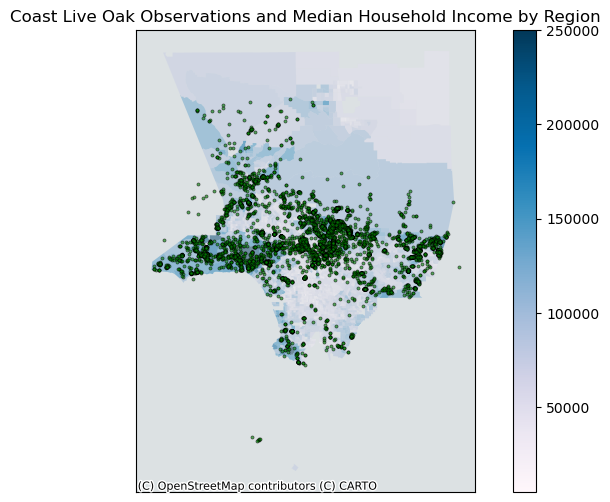

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# Load Coast Live Oak data (observations)
df_oak = pd.read_csv("Group Data/coastliveoaksobservations.csv")

# Load median household income data (GeoJSON format)
income_geojson = gpd.read_file("tracts_mhhi_geojson_output.geojson")  

# Convert Coast Live Oak data to GeoDataFrame
gdf_oak = gpd.GeoDataFrame(df_oak, geometry=gpd.points_from_xy(df_oak.longitude, df_oak.latitude), crs="EPSG:4326")

# Perform a spatial join (matching the oak points to the income polygons)
gdf_oak = gdf_oak.sjoin(income_geojson, how="left", predicate="within")

# Plot the map
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the income polygons (colored by median income)
income_geojson.plot(ax=ax, column='med_hh_income', cmap='PuBu', alpha=0.5, legend=True)

# Plot the Coast Live Oak observations (green points)
gdf_oak.plot(ax=ax, marker='o', color='green', markersize=5, alpha=0.6, edgecolor='black', linewidth=0.5)

# Add light gray basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8)

# Formatting
ax.set_title("Coast Live Oak Observations and Median Household Income by Region")
ax.set_xticks([])  # Hide axis labels
ax.set_yticks([])

# Save and show
plt.savefig("oak_income_spatial_join_geojson.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
trees_by_tract = gdf_oak.FIPS.value_counts().rename_axis('FIPS').reset_index(name='tree_count')
trees_by_tract

,FIPS,tree_count
0,6037930400,619
1,6037463700,479
2,6037461700,478
3,6037980009,439
4,6037460001,405
...,...,...
584,6037651302,1
585,6037301902,1
586,6037432202,1
587,6037577800,1


<Axes: xlabel='FIPS'>

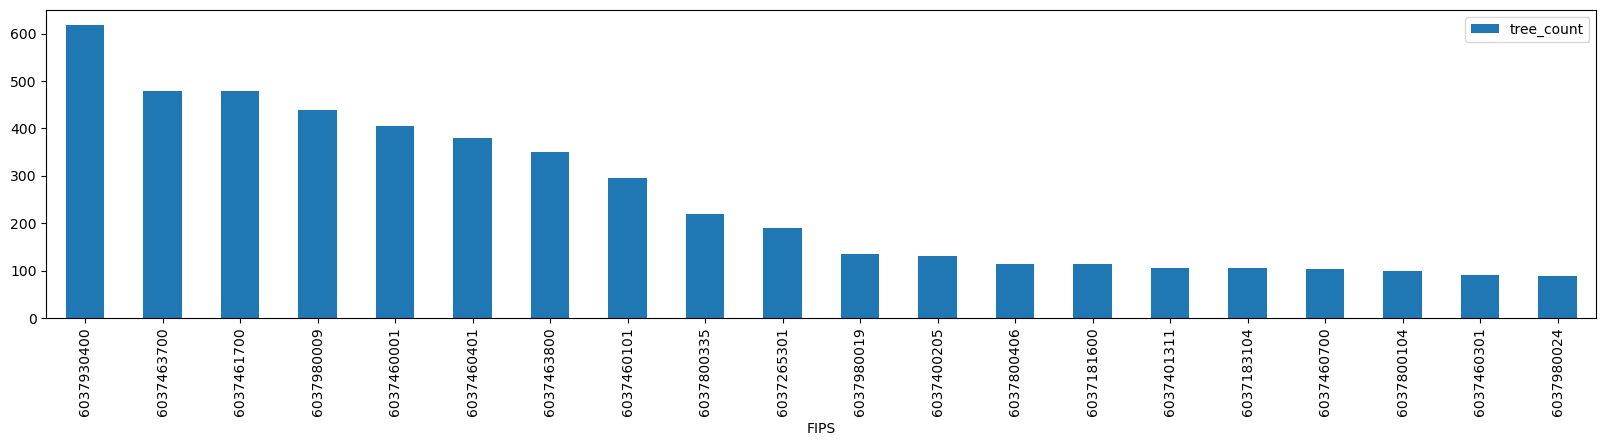

In [81]:
trees_by_tract[:20].plot.bar(figsize=(20,4),
                             x='FIPS',
                             y='tree_count')

<Axes: ylabel='Frequency'>

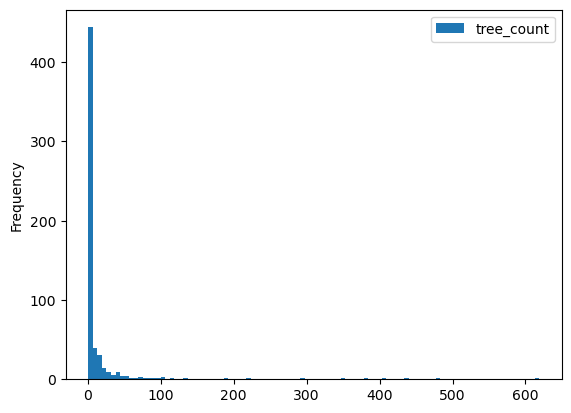

In [82]:
trees_by_tract.plot.hist(bins=100)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f0f2bfad450>,
 'caps': [<matplotlib.lines.Line2D at 0x7f0f2c7eb3d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f0f340853d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f0f2c5cc210>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f0f2c7d3810>],
 'means': []}

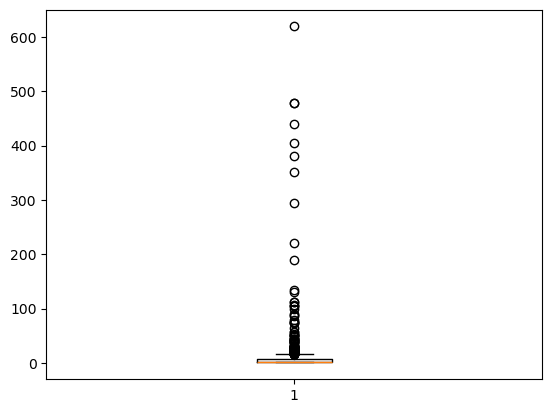

In [52]:
plt.boxplot(trees_by_tract.tree_count)

For next step, it would be good to do Normalizing: trees per 1000 homes in a tract -- will hold on doing that for the final

For now, I will skip the normalization

### Chloropleth map

In [13]:
type(trees_by_tract)

pandas.core.frame.DataFrame

In [14]:
# Ensure the 'FIPS' columns in both DataFrames are of the same type
trees_by_tract['FIPS'] = trees_by_tract['FIPS'].astype(str)
income_geojson['FIPS'] = income_geojson['FIPS'].astype(str)

# Merge the DataFrames on the 'FIPS' column
merged_gdf = income_geojson.merge(trees_by_tract, on='FIPS')

# Display the first few rows of the merged GeoDataFrame
merged_gdf.head()

,CT20,FIPS,tract,med_hh_income,med_hh_income_universe,ami_category,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area,Shape__Length,geometry,tree_count
0,101110,6037101110,6037101110,74625.0,1505,Low Income,Yes,No,Yes,District 5,Los Angeles - Tujunga,SPA 2 - San Fernando,2736,1.232981e+07,14765.649004,"POLYGON ((-118.29793 34.26323, -118.30082 34.2...",1
1,101300,6037101300,6037101300,87066.0,1419,Low Income,No,No,Yes,District 5,Los Angeles - Tujunga,SPA 2 - San Fernando,2741,2.769482e+07,28700.870571,"POLYGON ((-118.26528 34.25238, -118.26539 34.2...",7
2,101400,6037101400,6037101400,66210.0,1336,Low Income,Yes,No,Yes,District 5,Los Angeles - Tujunga,SPA 2 - San Fernando,2742,6.786798e+07,41887.332373,"POLYGON ((-118.29946 34.25598, -118.30027 34.2...",5
3,102104,6037102104,6037102104,98973.0,1340,Above Moderate Income,No,No,No,District 5,Los Angeles - Sun Valley,SPA 2 - San Fernando,2744,1.793336e+07,27118.708156,"POLYGON ((-118.33807 34.22228, -118.33822 34.2...",1
4,102107,6037102107,6037102107,83200.0,1232,Low Income,No,No,Yes,District 5,Los Angeles - Sunland,SPA 2 - San Fernando,2746,1.391218e+08,63442.656486,"POLYGON ((-118.33001 34.25968, -118.33004 34.2...",8


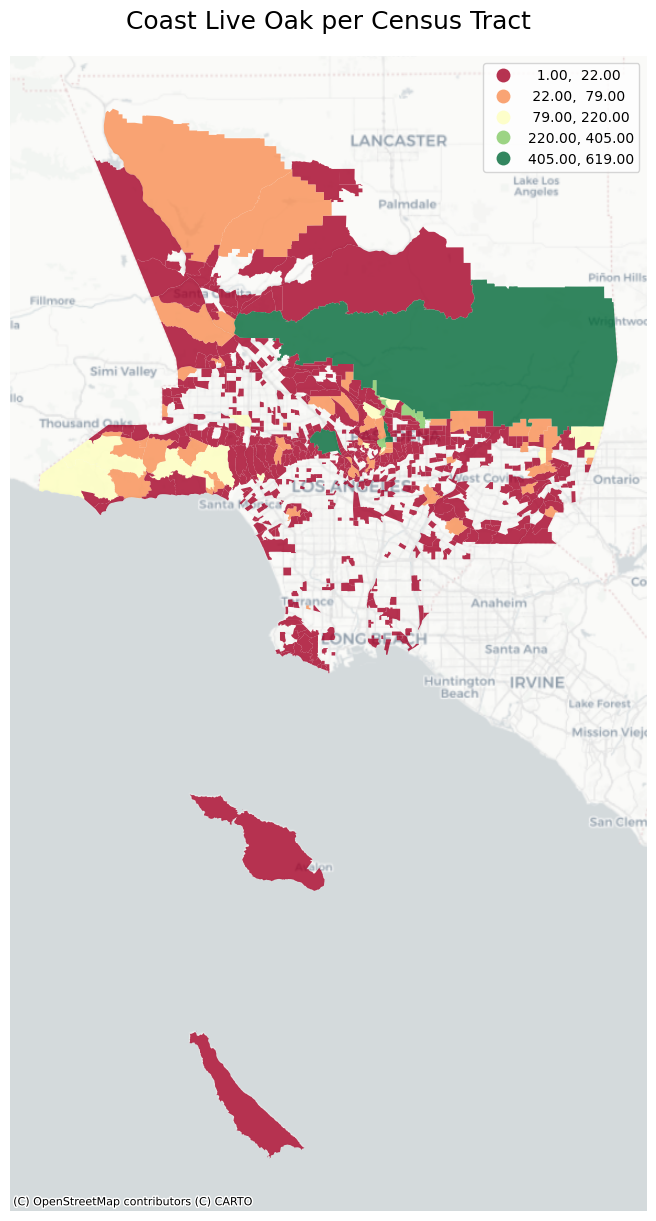

In [15]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify as mc

fig, ax = plt.subplots(figsize=(15, 15))

# Define the classification scheme
classifier = mc.NaturalBreaks(merged_gdf['tree_count'], k=7)

# Plot the GeoDataFrame with the specified classification
merged_gdf.plot(
    ax=ax,
    column='tree_count',
    legend=True,
    alpha=0.8,
    cmap='RdYlGn', 
    scheme='naturalbreaks',
    classification_kwds={'bins': classifier.bins}
)

ax.axis('off')
ax.set_title('Coast Live Oak per Census Tract', fontsize=18, pad=20)

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=income_geojson.crs.to_string())

plt.show()


This is an interesting map as it shows coast live oak density across the county (by census tract). This would be interesting to somehow overlay with burn scars from the recent fires. 

Spatial Weights

In [16]:
# calculate spatial weight
wq =  lps.weights.KNN.from_dataframe(merged_gdf,k=8)

# Row-standardization
wq.transform = 'r'

Spatial Lag

In [17]:
# create a new column for the spatial lag
merged_gdf['tree_count_lag'] = lps.weights.lag_spatial(wq, merged_gdf['tree_count'])

In [18]:
merged_gdf.sample(10)[['FIPS','tree_count','tree_count_lag']]

,FIPS,tree_count,tree_count_lag
230,6037275604,8,1.500
524,6037920042,2,3.500
286,6037401311,106,19.625
99,6037143605,1,1.750
20,6037108103,44,5.875
22,6037108202,7,10.250
503,6037800103,45,16.375
292,6037402002,2,31.250
367,6037460101,295,56.750
391,6037462600,2,5.250


In [19]:
merged_gdf['tree_lag_diff'] = merged_gdf['tree_count'] - merged_gdf['tree_count_lag']

In [20]:
merged_gdf.sort_values(by='tree_lag_diff')

,CT20,FIPS,tract,med_hh_income,med_hh_income_universe,ami_category,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area,Shape__Length,geometry,tree_count,tree_count_lag,tree_lag_diff
382,461600,6037461600,6037461600,80231.0,1810,Low Income,No,No,Yes,District 5,City of Pasadena,SPA 3 - San Gabriel,3174,1.785575e+07,17782.174061,"POLYGON ((-118.15068 34.16885, -118.15219 34.1...",4,131.125,-127.125
384,461901,6037461901,6037461901,49583.0,1710,Very Low Income,Yes,No,Yes,District 5,City of Pasadena,SPA 3 - San Gabriel,3176,9.449256e+06,13415.358011,"POLYGON ((-118.14154 34.1578, -118.14173 34.15...",1,121.625,-120.625
370,460302,6037460302,6037460302,68615.0,1623,Low Income,Yes,No,Yes,District 5,Unincorporated - Altadena,SPA 3 - San Gabriel,3159,1.412074e+07,17543.750549,"POLYGON ((-118.16015 34.19873, -118.16065 34.1...",4,123.750,-119.750
385,461902,6037461902,6037461902,36409.0,1166,Very Low Income,Yes,Yes,Yes,District 5,City of Pasadena,SPA 3 - San Gabriel,3177,8.983693e+06,12373.183590,"POLYGON ((-118.14147 34.15202, -118.14162 34.1...",6,121.000,-115.000
376,460800,6037460800,6037460800,221375.0,1137,Above Moderate Income,No,No,No,District 5,City of Pasadena,SPA 3 - San Gabriel,3165,7.296277e+07,41639.371390,"POLYGON ((-118.17496 34.18499, -118.1752 34.18...",73,169.750,-96.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,461700,6037461700,6037461700,137321.0,644,Above Moderate Income,No,No,No,District 5,City of Pasadena,SPA 3 - San Gabriel,3175,2.368704e+07,27347.538724,"POLYGON ((-118.1631 34.17028, -118.16654 34.17...",478,115.500,362.500
366,460001,6037460001,6037460001,194375.0,571,Above Moderate Income,No,No,No,District 5,Unincorporated - East Pasadena,SPA 3 - San Gabriel,3154,5.589876e+07,48331.610394,"POLYGON ((-118.06567 34.17934, -118.06602 34.1...",405,40.125,364.875
399,463700,6037463700,6037463700,145638.0,1625,Above Moderate Income,No,No,No,District 5,City of Pasadena,SPA 3 - San Gabriel,3327,1.859863e+07,17865.140494,"POLYGON ((-118.15526 34.14576, -118.15534 34.1...",479,113.375,365.625
552,980009,6037980009,6037980009,NaN,0,None,None,None,None,District 5,Los Angeles - Los Feliz,SPA 4 - Metro,4427,2.284265e+08,78138.601743,"POLYGON ((-118.30782 34.16114, -118.30786 34.1...",439,3.625,435.375


In [21]:
gdf_donut = merged_gdf.sort_values(by='tree_lag_diff').head(1)
gdf_donut

,CT20,FIPS,tract,med_hh_income,med_hh_income_universe,ami_category,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area,Shape__Length,geometry,tree_count,tree_count_lag,tree_lag_diff
382,461600,6037461600,6037461600,80231.0,1810,Low Income,No,No,Yes,District 5,City of Pasadena,SPA 3 - San Gabriel,3174,1.785575e+07,17782.174061,"POLYGON ((-118.15068 34.16885, -118.15219 34.1...",4,131.125,-127.125


In [22]:
# the FIPS with highest positive difference
gdf_diamond = merged_gdf.sort_values(by='tree_lag_diff').tail(1)
gdf_diamond

,CT20,FIPS,tract,med_hh_income,med_hh_income_universe,ami_category,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area,Shape__Length,geometry,tree_count,tree_count_lag,tree_lag_diff
550,930400,6037930400,6037930400,102778.0,384,Above Moderate Income,No,No,No,District 5,Unincorporated - Angeles National Forest,SPA 3 - San Gabriel,4418,1.608691e+10,915242.577112,"POLYGON ((-117.65525 34.39723, -117.65864 34.3...",619,11.625,607.375


In [23]:
# map the donut
gdf_donut.explore(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                  attr='Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community')

In [24]:
# map the diamond
gdf_diamond.explore(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                  attr='Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community')

/opt/conda/lib/python3.11/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 26 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


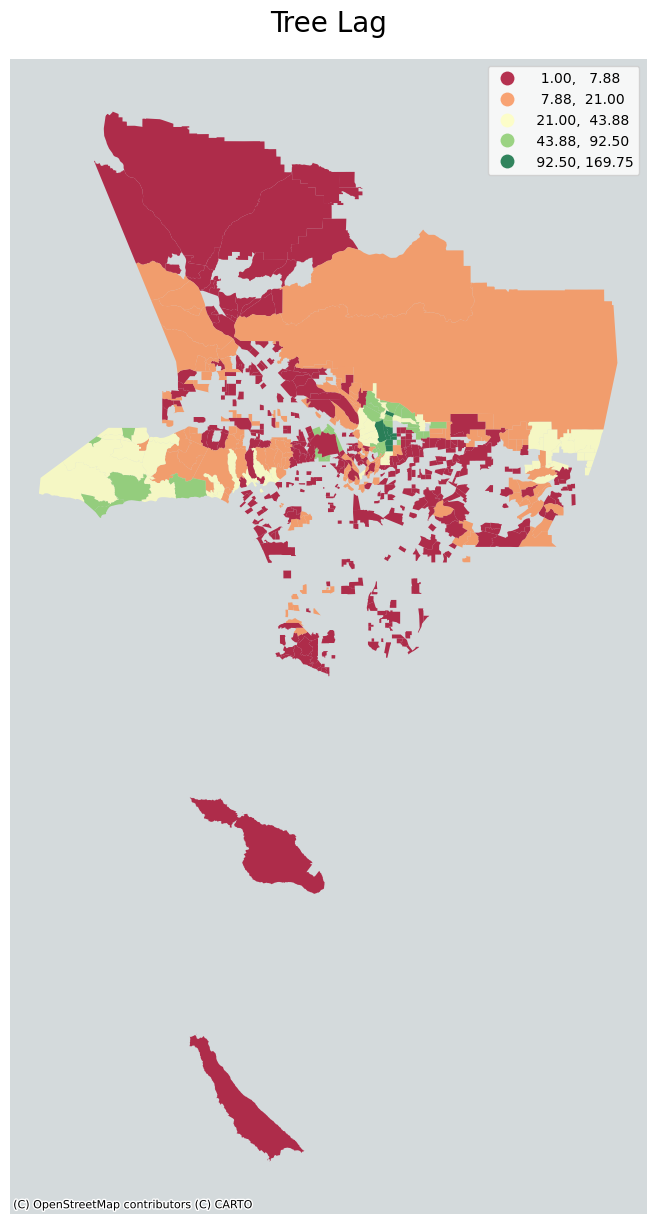

In [25]:
# use subplots that make it easier to create multiple layered maps
fig, ax = plt.subplots(figsize=(15, 15))

# spatial lag choropleth
merged_gdf.plot(ax=ax,
         figsize=(15,15),
         column='tree_count_lag',
         legend=True,
         alpha=0.8,
         cmap='RdYlGn',
         scheme='naturalbreaks')

ax.axis('off')
ax.set_title('Tree Lag',fontsize=20,pad=20)

ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

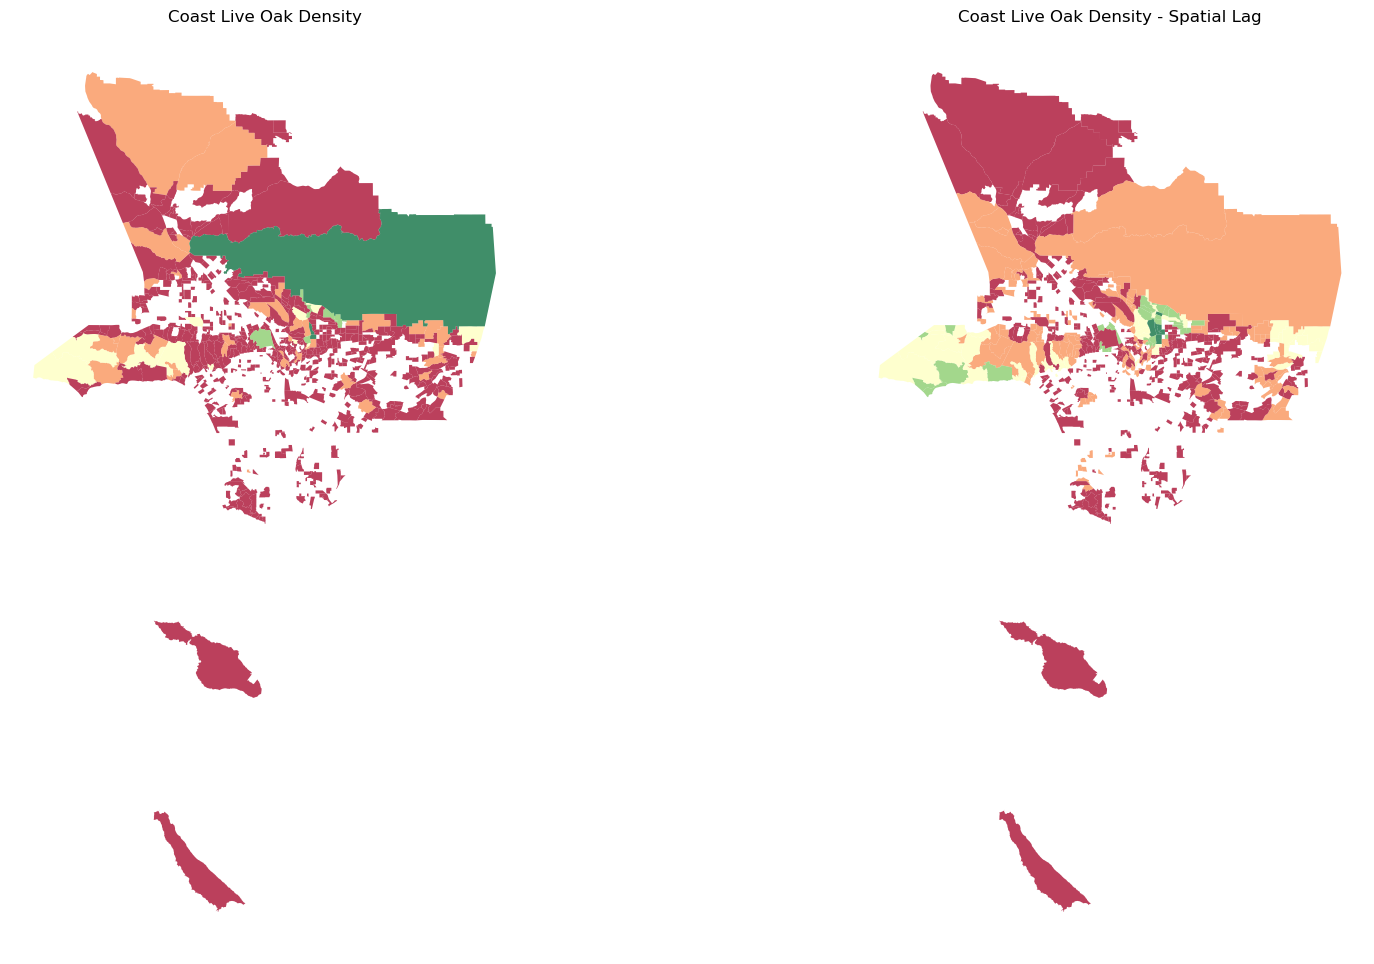

In [26]:
# create the 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# two subplots produces ax[0] (left) and ax[1] (right)

# regular count map on the left
merged_gdf.plot(ax=ax[0], # this assigns the map to the left subplot
         column='tree_count', 
         cmap='RdYlGn', 
         scheme='naturalbreaks',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75, 
           )


ax[0].axis("off")
ax[0].set_title("Coast Live Oak Density")

# spatial lag map on the right
merged_gdf.plot(ax=ax[1], # this assigns the map to the right subplot
         column='tree_count_lag', 
         cmap='RdYlGn', 
         scheme='naturalbreaks',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75
           )

ax[1].axis("off")
ax[1].set_title("Coast Live Oak Density - Spatial Lag")

plt.show()

Moran's Plot

In [27]:
y = merged_gdf.tree_count
moran = Moran(y, wq)
moran.I

np.float64(0.10945926039240812)

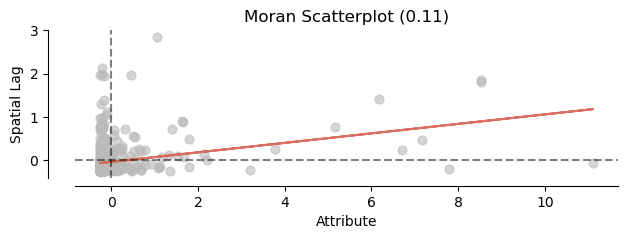

In [28]:
fig, ax = moran_scatterplot(moran, aspect_equal=True)
plt.show()

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.11', ylabel='Density'>)

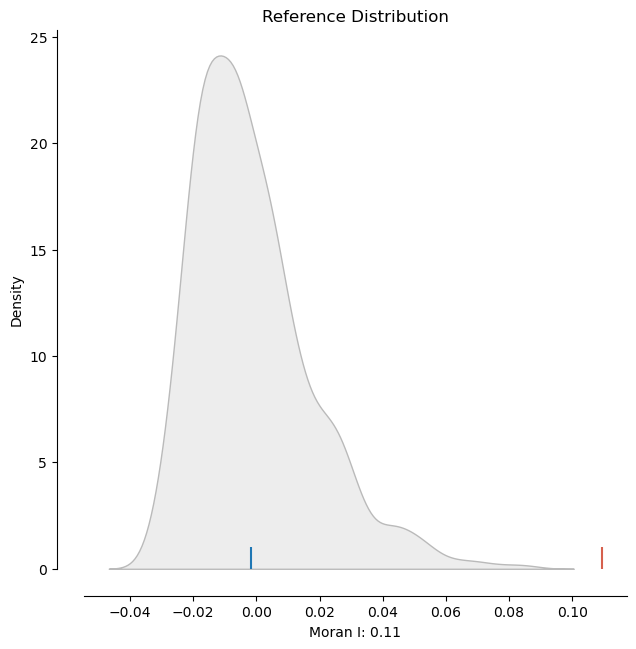

In [29]:
plot_moran_simulation(moran,aspect_equal=False)

Spatial Autocorrelation Map

In [30]:
# calculate local moran values
lisa = esda.moran.Moran_Local(y, wq)

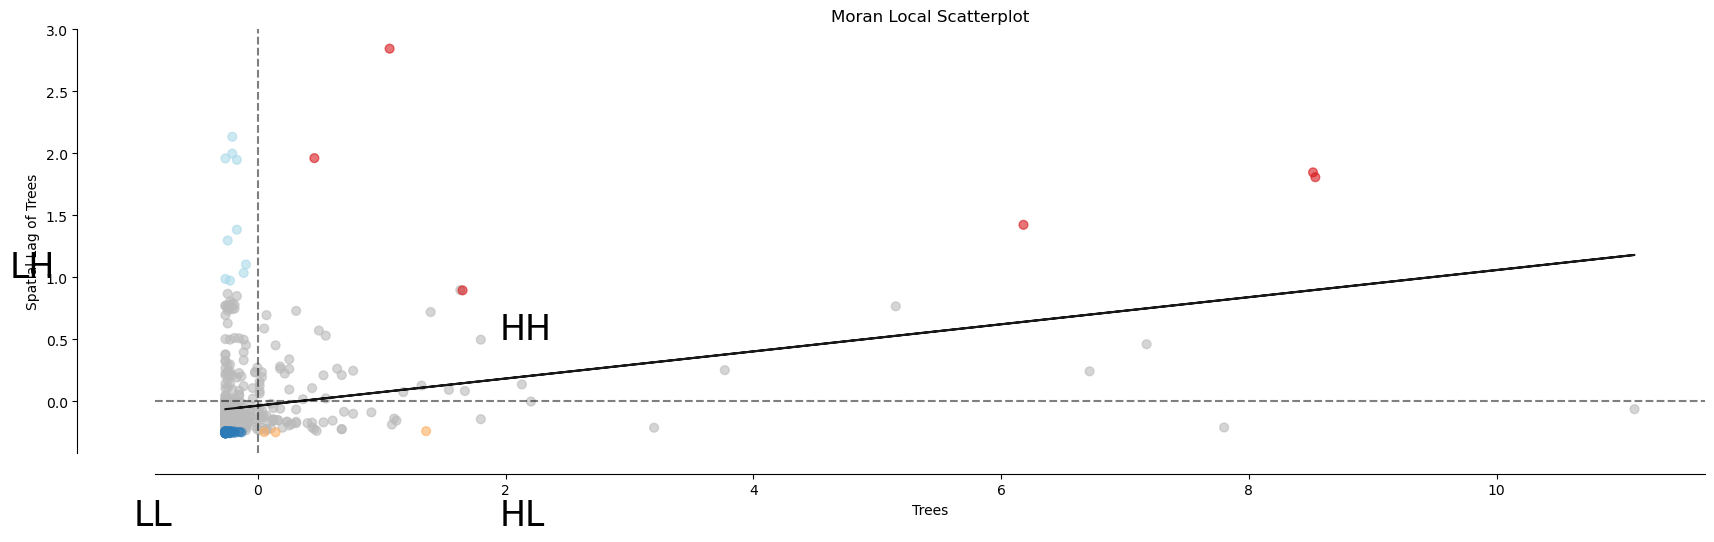

In [32]:
# Plot
fig,ax = plt.subplots(figsize=(20,15))

moran_scatterplot(lisa, ax=ax, p=0.05)
ax.set_xlabel("Trees")
ax.set_ylabel('Spatial Lag of Trees')

# add some labels
plt.text(1.95, 0.5, "HH", fontsize=25)
plt.text(1.95, -1, "HL", fontsize=25)
plt.text(-2, 1, "LH", fontsize=25)
plt.text(-1, -1, "LL", fontsize=25)
plt.show()

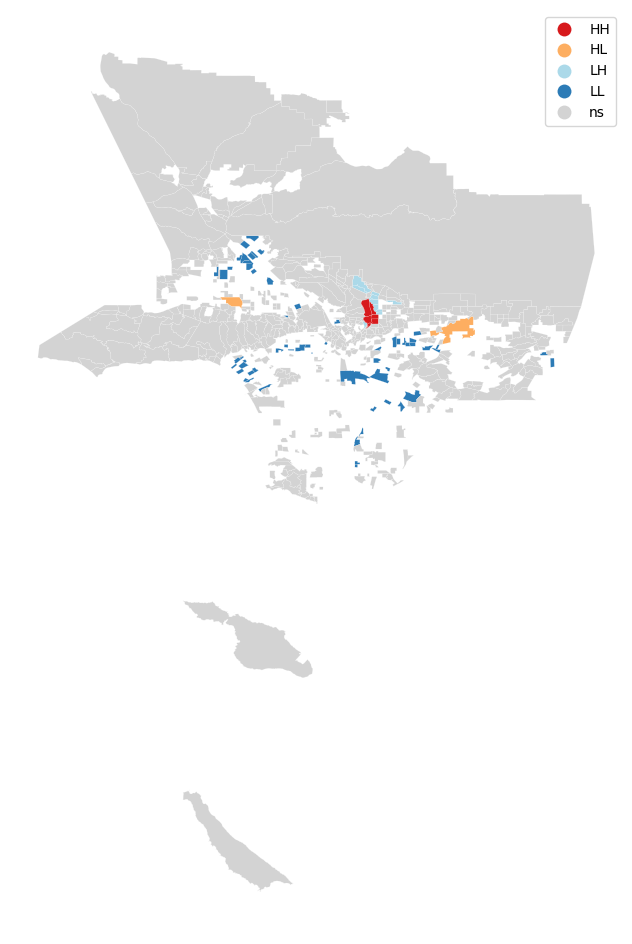

In [33]:
fig, ax = plt.subplots(figsize=(14,12))
lisa_cluster(lisa, merged_gdf, p=0.05, ax=ax)
plt.show()

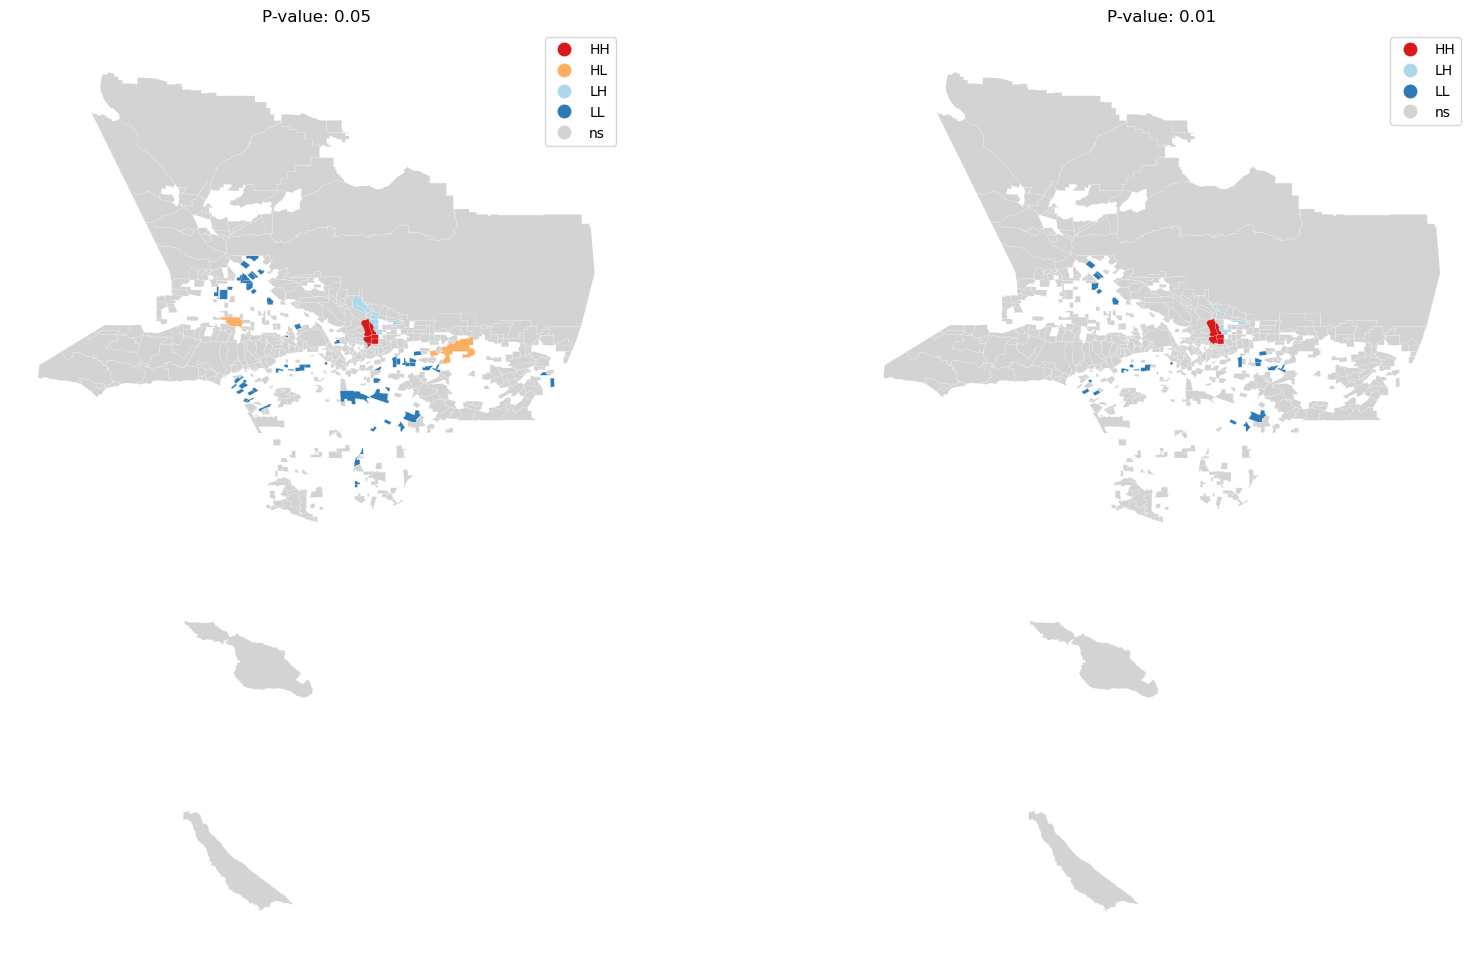

In [34]:
# create the 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# regular count map on the left
lisa_cluster(lisa, merged_gdf, p=0.05, ax=ax[0])

ax[0].axis("off")
ax[0].set_title("P-value: 0.05")

# spatial lag map on the right
lisa_cluster(lisa, merged_gdf, p=0.01, ax=ax[1])
ax[1].axis("off")
ax[1].set_title("P-value: 0.01")

plt.show()

The spatial autocorrelation for coast live oak density shows a random spatial pattern with no significant autocorrelation. For next steps, we should merge housing data with coast live oak density and median household income. We might be able to find more statistically significant information that way. 